# Lab 5: Frequency Domain Analysis and Filtering

## Theory

### Discrete Fourier Transform (DFT)
DFT converts spatial data into frequency components.

F(u, v) = ΣΣ f(x, y) e^(−j2π(ux/M + vy/N))

---

### Frequency Components
- Low frequency → smooth regions
- High frequency → edges and noise

---

### Filters

#### Low Pass Filter
Removes high-frequency components → smoothing

#### High Pass Filter
Removes low-frequency components → edge enhancement

---

### Median Filter
Non-linear filter effective for removing impulse noise.

---

### Inverse DFT
Converts frequency domain data back to spatial domain, reconstructing the image.

# Experiment 1: Gaussian Filtering

## Problem
To apply Gaussian filter to smooth an image.

## Theory
Gaussian filtering uses a weighted kernel to reduce noise and smooth the image.

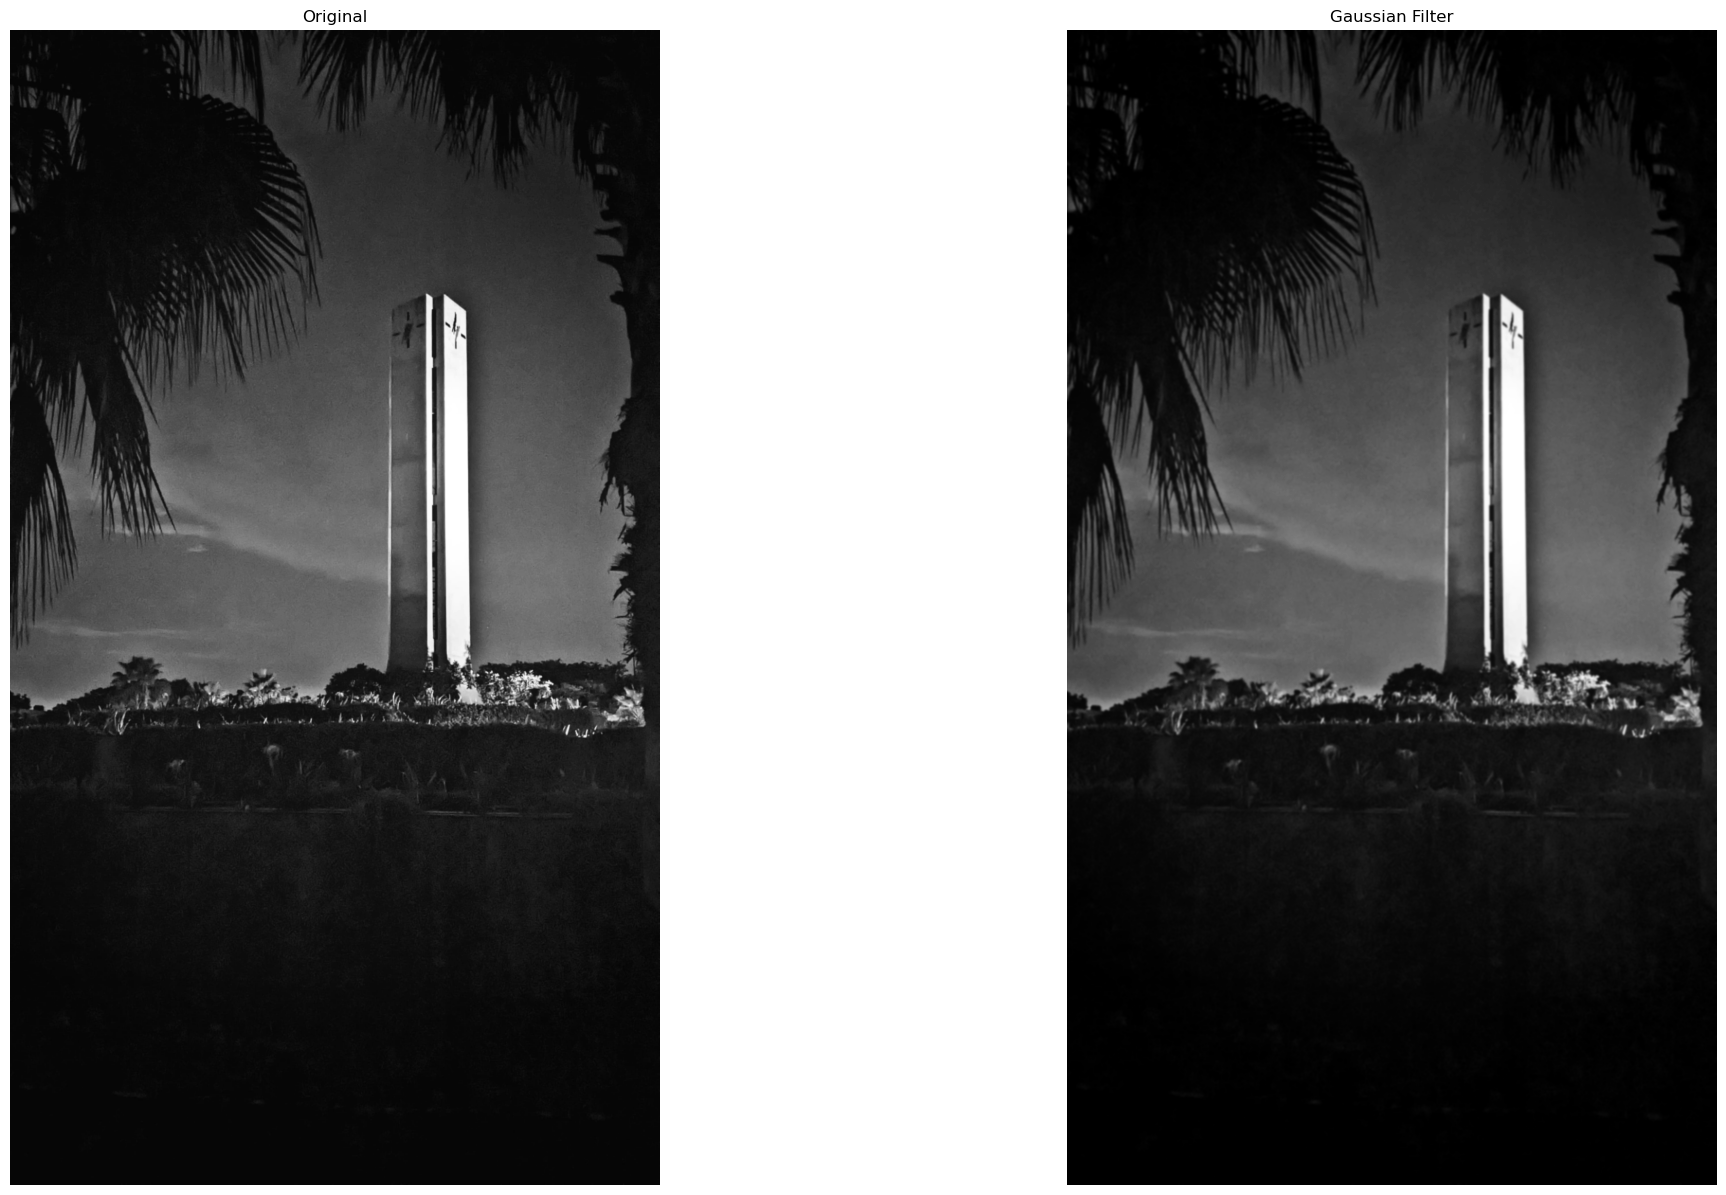

In [41]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

gaussian = cv2.GaussianBlur(img, (15,15), 0)

plt.figure(figsize=(25,15))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Filter")
plt.axis('off')

plt.show()

# Experiment 2: Frequency Domain Filtering

## Problem
To apply filtering in frequency domain using DFT.

## Theory
DFT converts image from spatial domain to frequency domain.
Low frequencies → smooth regions  
High frequencies → edges/noise

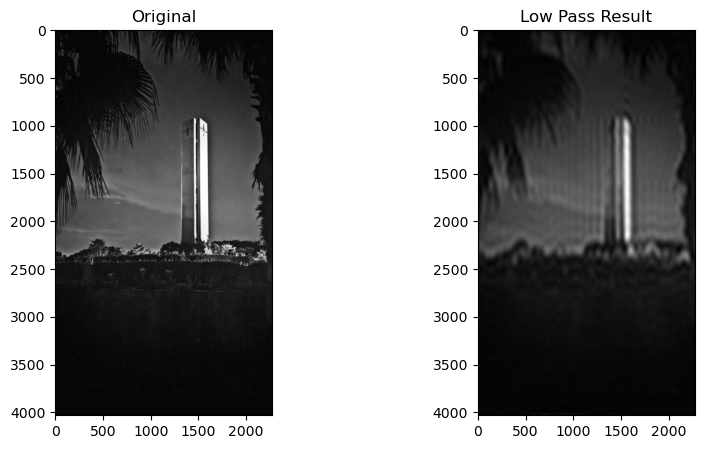

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# DFT
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Mask (low-pass filter)
rows, cols = img.shape
crow, ccol = rows//2, cols//2

mask = np.zeros((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# Apply mask
filtered = dft_shift * mask

# Inverse DFT
f_ishift = np.fft.ifftshift(filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(img_back, cmap='gray')
plt.title("Low Pass Result")

plt.show()

# Experiment 3: Median Filter

## Problem
To remove noise using median filtering.

## Theory
Median filter replaces each pixel with median of neighbors.
It is effective for salt and pepper noise.

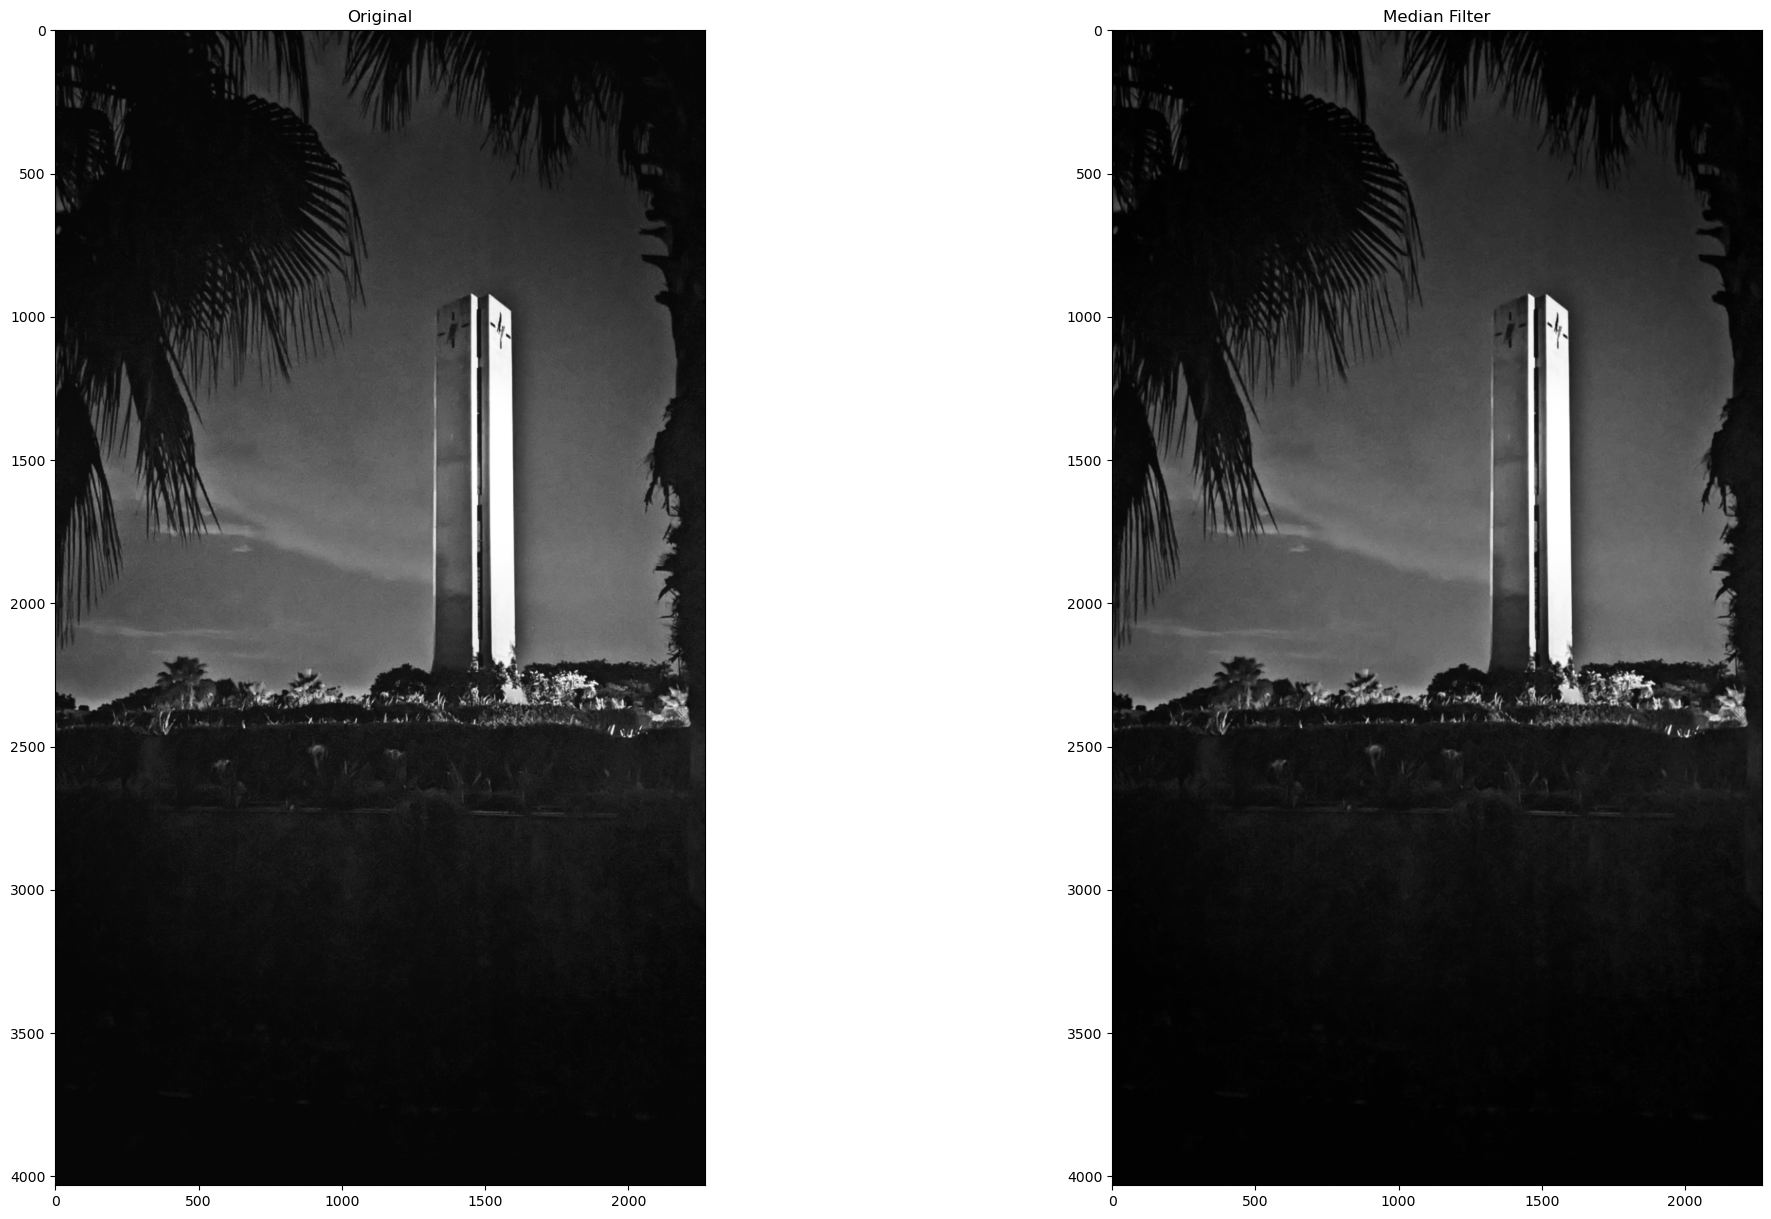

In [45]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

median = cv2.medianBlur(img, 5)

plt.figure(figsize=(25,15))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(median, cmap='gray')
plt.title("Median Filter")

plt.show()

# Experiment 4: Forward and Inverse DFT

## Problem
To compute DFT and reconstruct image using inverse DFT.

## Theory
DFT converts image into frequency components.
Inverse DFT reconstructs the image back.

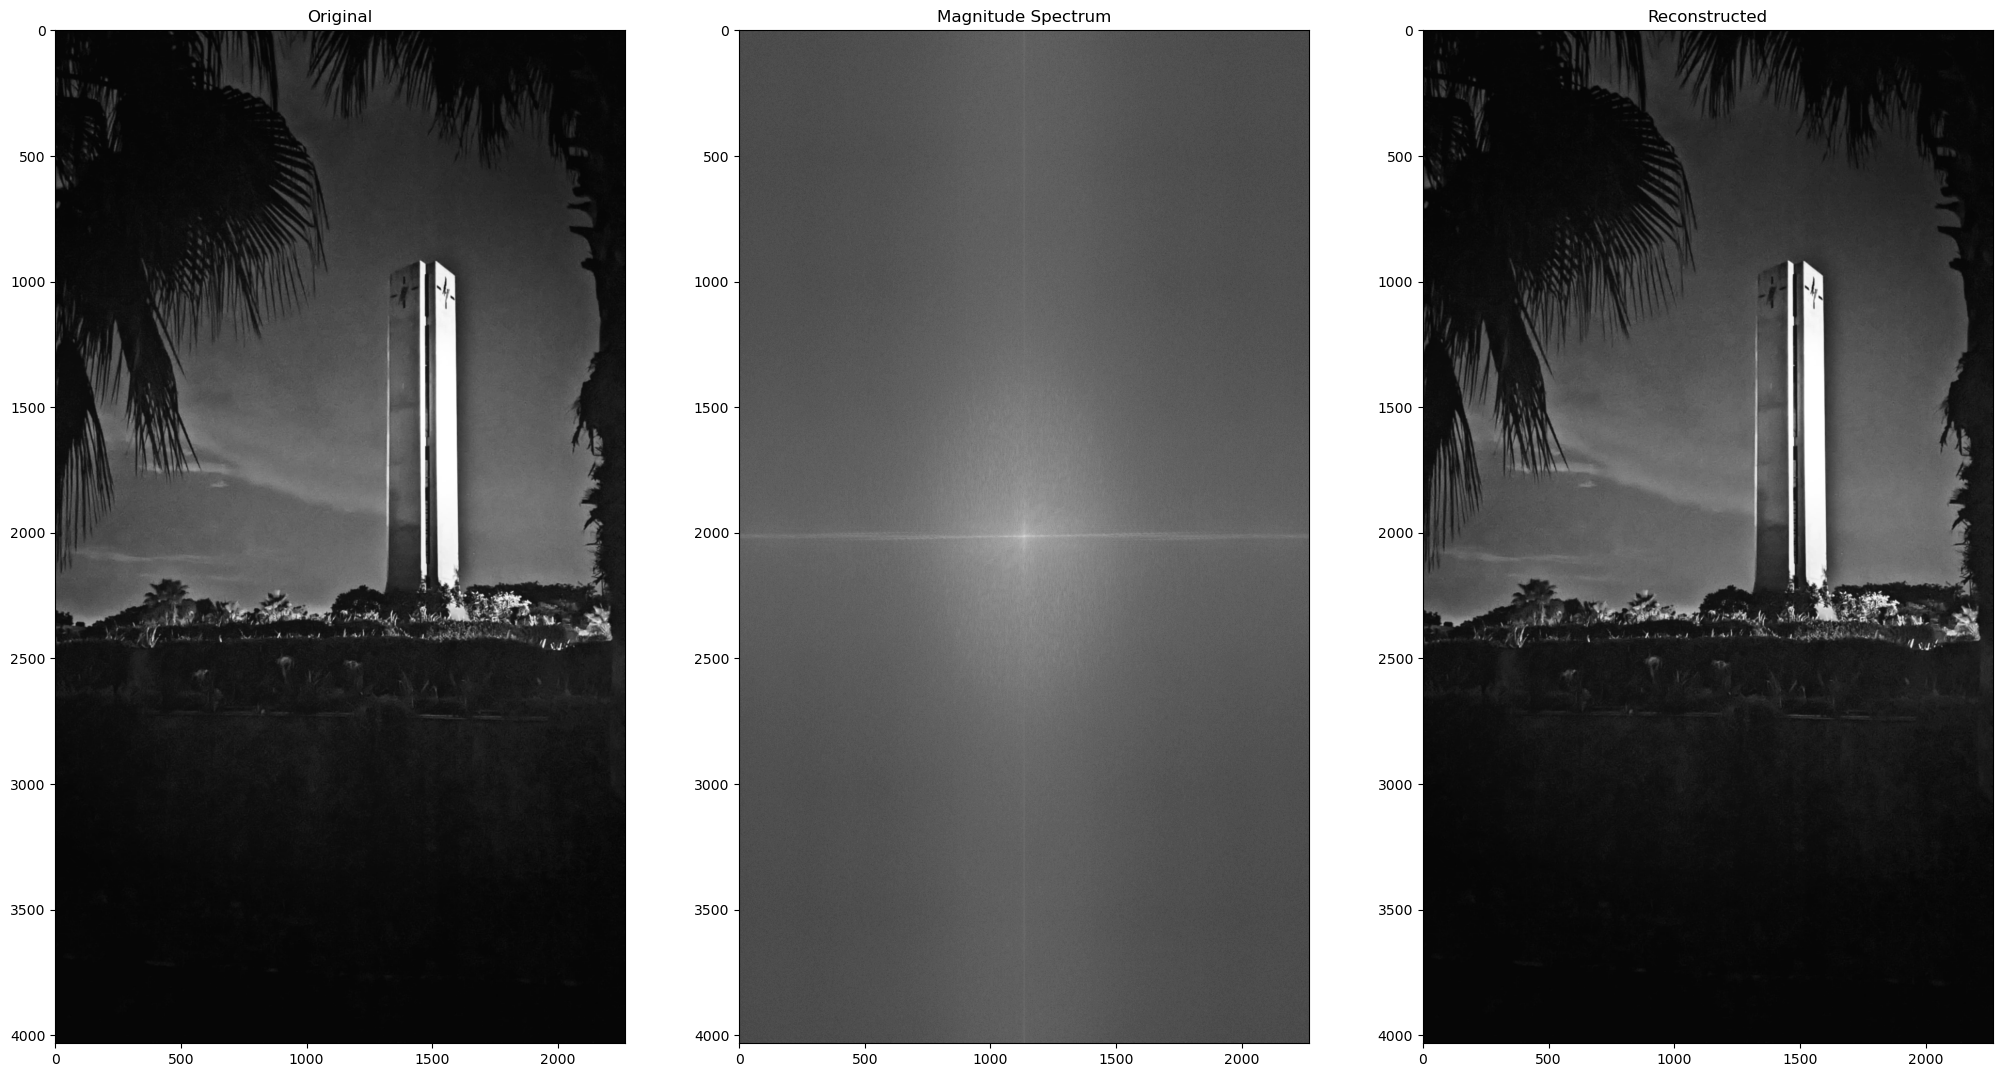

In [47]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# Forward DFT
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Magnitude spectrum
magnitude = 20 * np.log(np.abs(dft_shift) + 1)

# Inverse DFT
f_ishift = np.fft.ifftshift(dft_shift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(25,15))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")

plt.subplot(1,3,3)
plt.imshow(img_back, cmap='gray')
plt.title("Reconstructed")

plt.show()